In [12]:
import pandas as pd
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [13]:
# wiek a ostrość wzroku: "jak rozkłada się ostrosc w grupach wiekowych"
## filtruje tylko ostrość wzroku do dali
df_va = df[df["Question"] == "Presenting visual acuity"]
## Sprzątanie danych 
### usuwanie wierszy gdzie nie ma danych
df_va = df_va.dropna(subset=["Data_Value", "Age", "Response"])
### usuwanie "all ages" i wiku "65+"
df_va = df_va[df_va["Age"] != "All ages"]
df_va = df_va[df_va["Age"] != "65 years and older"]
### porządkowanie wieku w odpowiedniej kolejności
age_order = ["65-69 years", "70-74 years", "75-79 years", "80-84 years", "85-89 years", "90 years and older"]
df_va["Age"] = pd.Categorical(df_va["Age"], categories=age_order, ordered=True)
### usunięcie odpowiedzi "Missing presenting aquity"
df_va = df_va[df_va["Response"] != "Missing presenting acuity"]
print(df_va.head(5))


    YearStart  YearEnd StateAbbr LocationAbbr LocationDesc GeographicLevel  \
6        2022     2022        US           US     National        National   
24       2022     2022        US           US     National        National   
26       2022     2022        US           US     National        National   
31       2022     2022        US           US     National        National   
43       2022     2022        US           US     National        National   

   DataSource            Topic                Category  \
6       NHATS  Visual Function  Measured Visual Acuity   
24      NHATS  Visual Function  Measured Visual Acuity   
26      NHATS  Visual Function  Measured Visual Acuity   
31      NHATS  Visual Function  Measured Visual Acuity   
43      NHATS  Visual Function  Measured Visual Acuity   

                    Question  ... ResponseID DataValueTypeID      AgeID SexID  \
6   Presenting visual acuity  ...     RVPNOR         CRDPREV    AGE6569  GALL   
24  Presenting visua

# Tworzenie wykresu dla WSZYSTKICH odpowiedzi związanych z widzeniem do dali a wiekiem


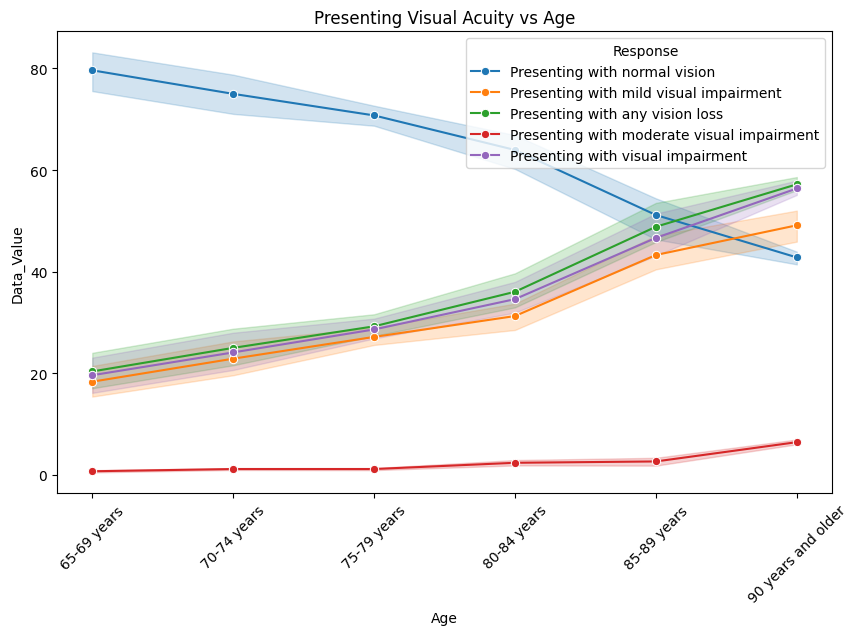

In [14]:
# tworzenie wykresu
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_va,
    x="Age",
    y="Data_Value",
    hue="Response",
    marker="o"
)

plt.title("Presenting Visual Acuity vs Age")
plt.xticks(rotation=45)
plt.show()

# Testy statystyczne - wybrano chi-kwadrat

In [15]:
# #opis trendu, chyba niepotrzebne
# print(df_va["Response"].unique())
# df_loss = df_va[df_va["Response"] == "Presenting with any vision loss"]

In [16]:
# # test chi-kwadrat 
# table = pd.pivot_table(
#     df_va,
#     values="Numerator",
#     index="Age",
#     columns="Response",
#     aggfunc="sum"
# )
# print (table)

In [17]:
# # test ch-kwadrat ciąg dalszy
# from scipy.stats import chi2_contingency

# chi2, p, dof, expected = chi2_contingency(table)

# print("chi2:", chi2)
# print("p-value:", p)

In [18]:
# inny test chi-kwadrat - CHYBA LEPSZY
from scipy.stats import chi2_contingency
# 1. Tworzenie tabeli kontyngencji (Crosstab)
# Wartości: Suma procentów (lub Sample_Size, jeśli masz tę kolumnę)
age_contingency = pd.crosstab(df_va["Age"], 
                               df_va["Response"], 
                               values=df_va["Data_Value"], 
                               aggfunc="sum").fillna(0)

print("Tabela kontyngencji (Wiek vs Widzenie):")
print(age_contingency)

# 2. Wykonanie testu Chi-kwadrat
chi2_a, p_a, dof_a, expected_a = chi2_contingency(age_contingency)

print(f"\n--- Wyniki testu Chi-kwadrat dla Wieku ---")
print(f"Statystyka Chi2: {chi2_a:.4f}")
print(f"Wartość p: {p_a:.4e}")
print(f"Stopnie swobody: {dof_a}")

# 3. Interpretacja
if p_a < 0.05:
    print("\nInterpretacja: Istnieje silna zależność między wiekiem a rozkładem jakości widzenia.")
else:
    print("\nInterpretacja: Nie stwierdzono istotnej zależności rozkładu widzenia od wieku.")

Tabela kontyngencji (Wiek vs Widzenie):
Response            Presenting with any vision loss  \
Age                                                   
65-69 years                                  224.09   
70-74 years                                  275.07   
75-79 years                                  321.73   
80-84 years                                  360.49   
85-89 years                                  488.44   
90 years and older                           514.74   

Response            Presenting with mild visual impairment  \
Age                                                          
65-69 years                                         201.87   
70-74 years                                         251.71   
75-79 years                                         298.81   
80-84 years                                         344.01   
85-89 years                                         432.86   
90 years and older                                  491.30   

Response            Pr

In [19]:
# Testem H Kruskala Wallisa z uwagi na to ze zmienna zalezna (wiek) jest zmienną porządkową (CZAT MÓWI: sprawdza, czy wartości ciągłe (Twoje procenty Data_Value) różnią się między grupami (wiek) )
from scipy import stats
# 1. Tworzenie listy grup do testu
# Zakładamy, że kolumna z wiekiem nazywa się "Age" lub "AgeGroup"
age_groups = df_va["Age"].unique()
groups_data = [df_va[df_va["Age"] == age]["Data_Value"].dropna() for age in age_groups]

# 2. Wykonanie testu Kruskala-Wallisa
stat, p_value = stats.kruskal(*groups_data)

print(f"--- Wyniki testu Kruskala-Wallisa dla Wieku ---")
print(f"Liczba grup wiekowych: {len(age_groups)}")
print(f"Statystyka H: {stat:.4f}")
print(f"Wartość p: {p_value:.4e}")

# 3. Interpretacja
if p_value < 0.05:
    print("\nInterpretacja: Istnieje istotna statystycznie różnica w widzeniu między grupami wiekowymi.")
else:
    print("\nInterpretacja: Brak istotnych różnic między grupami wiekowymi.")

--- Wyniki testu Kruskala-Wallisa dla Wieku ---
Liczba grup wiekowych: 6
Statystyka H: 36.1407
Wartość p: 8.9019e-07

Interpretacja: Istnieje istotna statystycznie różnica w widzeniu między grupami wiekowymi.
